# Домашняя работа №1 по RL

Подготовили Кочергина Ксения и Куканова Виктория, мехмат, группа 405


In [45]:
import numpy as np
import pandas as pd
import random
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import time
from scipy.stats import norm, beta
import matplotlib.pyplot as plt
from tqdm import tqdm
import plotly.io as pio

seed = 42
random.seed(seed)
np.random.seed(seed)

## Базовый уровень

Рассмотрим задачу трехрукого бандита - у агента есть 3 действия, каждое даёт случайную награду со своим неизвестным распределением.

1. $\epsilon$-greedy

Алгоритм:
* w.p. $1 - \epsilon$ выбираем действие с текущей максимальной оценённой ценностью (эксплуатация).
* w.p. $\epsilon$ выбираем случайное действие равномерно из всех (исследование).

Преимущества алгоритма:
    
    + простой
    + сохраняет исследование (если специально не уменьшаем $\epsilon$)

Недостатки:
    
    - w.p. $\epsilon$ может совершить неоптимальное действие даже когда агент уже обучился (в средах с высоким риском негативных наград это может быть фатально)
    - требуется настройка $\epsilon$ под конкретную задачу
    - Не учитывает неопределённость оценок


2. Upper confidence bound
   
Для каждого действия строим верхнюю доверительную границу (например, на основе неравенства Хёфдинга) и выбираем действие с максимальной границей: $a_t = \arg\max_a \left( \hat{Q}_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \right)$  
где $\hat{Q}_t(a)$ — средняя награда действия $a$ после $t$ шагов, $N_t(a)$ — сколько раз выбиралось $a$, $c$ — параметр, контролирующий уровень исследования.


In [51]:
class EpsilonGreedy:
    def __init__(self, n_actions, epsilon=0.1):
        self.n_actions = n_actions
        self.epsilon = epsilon
        self.counts = np.zeros(n_actions)
        self.values = np.zeros(n_actions)
    def select_action(self):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        else:
            return np.argmax(self.values)
    def update(self, action, reward):
        self.counts[action] += 1
        n = self.counts[action]
        self.values[action] += (reward - self.values[action]) / n

class UCB1:
    def __init__(self, n_actions, c=2.0):
        self.n_actions = n_actions
        self.c = c
        self.counts = np.zeros(n_actions)
        self.values = np.zeros(n_actions)
        self.t = 0
    def select_action(self):
        self.t += 1
        ucb_values = np.zeros(self.n_actions)
        for a in range(self.n_actions):
            if self.counts[a] == 0:
                return a
            else:
                bonus = self.c * np.sqrt(np.log(self.t) / self.counts[a])
                ucb_values[a] = self.values[a] + bonus
        return np.argmax(ucb_values)
    def update(self, action, reward):
        self.counts[action] += 1
        n = self.counts[action]
        self.values[action] += (reward - self.values[action]) / n

class ThompsonSampling:
    def __init__(self, n_actions, prior_mean=0, prior_std=10, reward_std=0.5):
        self.n_actions = n_actions
        self.reward_std = reward_std
        self.prior_mean = prior_mean
        self.prior_std = prior_std
        self.precision = 1.0 / (prior_std**2) * np.ones(n_actions)
        self.mean = prior_mean * np.ones(n_actions)
        self.sum_rewards = np.zeros(n_actions)
        self.counts = np.zeros(n_actions)
    def select_action(self):
        samples = np.random.normal(self.mean, 1.0 / np.sqrt(self.precision))
        return np.argmax(samples)
    def update(self, action, reward):
        var_reward = self.reward_std**2
        prior_precision = 1.0 / (self.prior_std**2)
        self.sum_rewards[action] += reward
        self.counts[action] += 1
        self.precision[action] = prior_precision + self.counts[action] / var_reward
        self.mean[action] = (self.prior_mean / (self.prior_std**2) +
                             self.sum_rewards[action] / var_reward) / self.precision[action]

In [54]:
def run_experiment(bandit_means, bandit_std, n_steps=1000, n_runs=50):
    n_actions = len(bandit_means)
    methods = {
        'ε-greedy (ε=0.1)': EpsilonGreedy(n_actions, epsilon=0.1),
        'ε-greedy (ε=0.01)': EpsilonGreedy(n_actions, epsilon=0.01),
        'UCB (c=2)': UCB1(n_actions, c=2.0),
        'UCB (c=100)': UCB1(n_actions, c=100.0),
        'Thompson Sampling (prior_mean=0)': ThompsonSampling(n_actions, prior_mean=0, prior_std=10, reward_std=bandit_std),
        'Thompson Sampling (prior_mean=10000)': ThompsonSampling(n_actions, prior_mean=10000, prior_std=10, reward_std=bandit_std)
    }
    
    results = {name: {'rewards': np.zeros((n_runs, n_steps)),
                      'regret': np.zeros((n_runs, n_steps)),
                      'optimal_pct': np.zeros((n_runs, n_steps))}
               for name in methods}
    optimal_action = np.argmax(bandit_means)
    
    for run in range(n_runs):
        agents = {
            'ε-greedy (ε=0.1)': EpsilonGreedy(n_actions, epsilon=0.1),
            'ε-greedy (ε=0.01)': EpsilonGreedy(n_actions, epsilon=0.01),
            'UCB (c=2)': UCB1(n_actions, c=2.0),
            'UCB (c=100)': UCB1(n_actions, c=100.0),
            'Thompson Sampling (prior_mean=0)': ThompsonSampling(n_actions, prior_mean=0, prior_std=10, reward_std=bandit_std),
            'Thompson Sampling (prior_mean=10000)': ThompsonSampling(n_actions, prior_mean=10000, prior_std=10, reward_std=bandit_std)
        }
        for step in range(n_steps):
            for name, agent in agents.items():
                action = agent.select_action()
                reward = np.random.normal(bandit_means[action], bandit_std)
                agent.update(action, reward)
                results[name]['rewards'][run, step] = reward
                optimal_reward = np.random.normal(bandit_means[optimal_action], bandit_std)
                results[name]['regret'][run, step] = (optimal_reward - reward)
                results[name]['optimal_pct'][run, step] = 1 if action == optimal_action else 0
    
    avg_rewards = {name: np.mean(results[name]['rewards'], axis=0) for name in results}
    cum_regret = {name: np.cumsum(np.mean(results[name]['regret'], axis=0)) for name in results}
    opt_rate = {name: np.cumsum(np.mean(results[name]['optimal_pct'], axis=0)) / np.arange(1, n_steps+1) for name in results}
    return avg_rewards, cum_regret, opt_rate

true_means = [0.2, 0.5, 0.8]
std_dev = 0.5
n_steps = 1000
n_runs = 50

avg_rewards, cum_regret, opt_rate = run_experiment(true_means, std_dev, n_steps, n_runs)

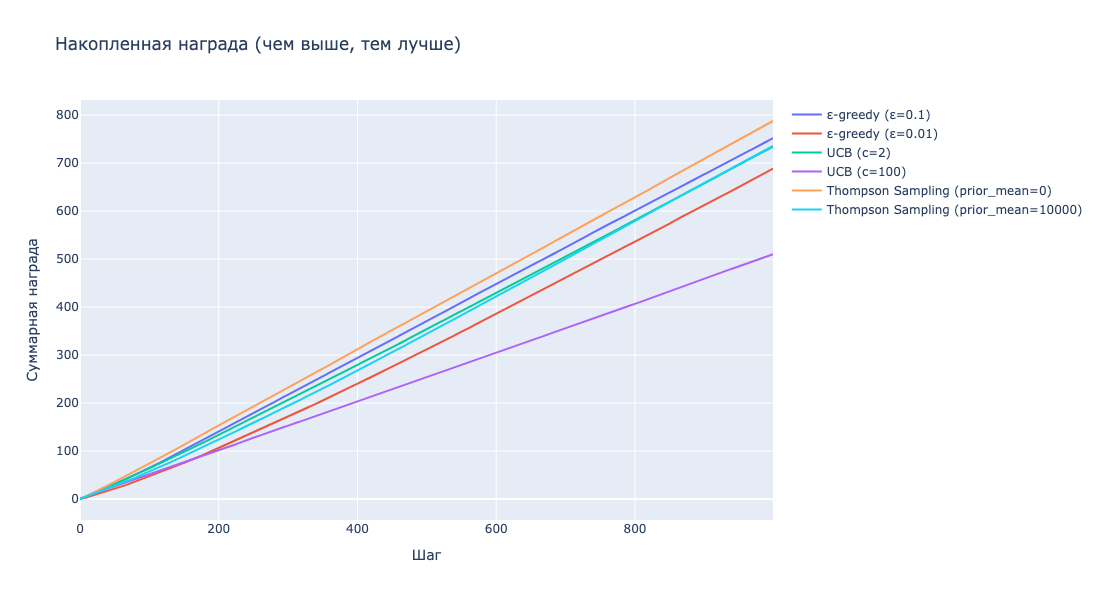

In [59]:
pio.renderers.default = 'png'

fig_cum_reward = go.Figure()
for name, rewards in avg_rewards.items():
    cum_rewards = np.cumsum(rewards)
    fig_cum_reward.add_trace(go.Scatter(x=list(range(n_steps)), y=cum_rewards,
                                        mode='lines', name=name))
fig_cum_reward.update_layout(title='Накопленная награда (чем выше, тем лучше)',
                             xaxis_title='Шаг', yaxis_title='Суммарная награда', height=600, width=1100,
                             hovermode='x unified')
fig_cum_reward.show()

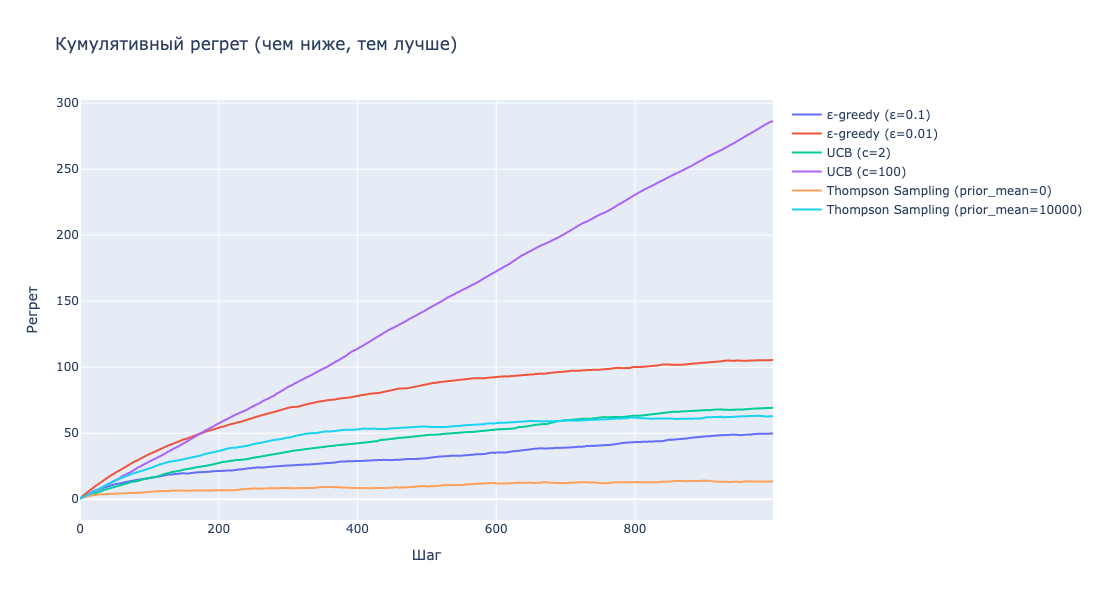

In [62]:
fig_cum_regret = go.Figure()
for name, regret in cum_regret.items():
    fig_cum_regret.add_trace(go.Scatter(x=list(range(n_steps)), y=regret,
                                        mode='lines', name=name))
fig_cum_regret.update_layout(title='Кумулятивный регрет (чем ниже, тем лучше)',
                             xaxis_title='Шаг', yaxis_title='Регрет', height=600, width=1100,
                             hovermode='x unified')
fig_cum_regret.show()

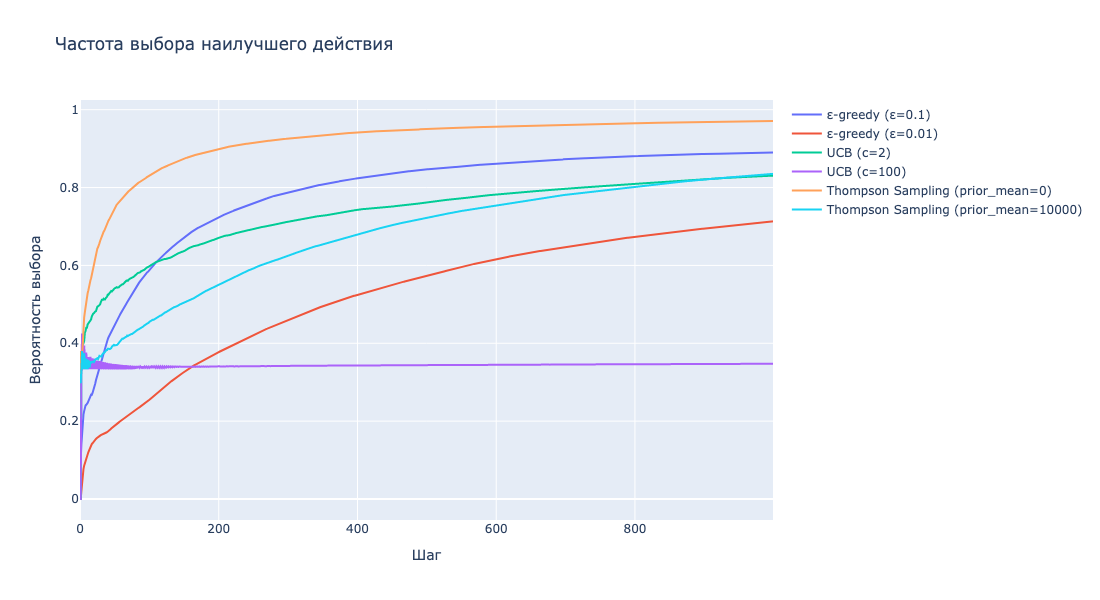

In [65]:
fig_opt_rate = go.Figure()
for name, rate in opt_rate.items():
    fig_opt_rate.add_trace(go.Scatter(x=list(range(n_steps)), y=rate,
                                      mode='lines', name=name))
fig_opt_rate.update_layout(title='Частота выбора наилучшего действия',
                           xaxis_title='Шаг', yaxis_title='Вероятность выбора', height=600, width=1100,
                           hovermode='x unified')
fig_opt_rate.show()

## Продвинутый уровень: Влияние коэффициента дисконтирования $\gamma$

Рассмотрим задачу: среда - плоский мир (size x size), где выбрана точка статра и финиша, между ними - путь в виде зигзара. Агент может совершать переходы влево, вправо, вниз, наверх, не выходя за пределы мира. Награда распределена по ячейкам так: -100 для клеток вне пути, -1 для клеток на зигзаге от старта до финиша. При попадении в точку финиша эпизод завершается. Задача агента - пройти от старта до финиша, максимизируя суммарный reward за путь.

Применим для этого алгоритм Value Iteration: $V_{k+1} = T_\gamma V_k$, $V_0 = 0$

где T - оператор Беллмана: $(T_\gamma V)(s) = \max_{a} \left[ r(s,a) + \gamma \sum_{s'} P(s'|s,a) V(s') \right]$

Результатом работы Value Iteration будет таблица приближения функции ценности действия V, по которой можно построить детерминированную политику, приближающую оптимальную (доказательство есть, например, в Richard S. Sutton, Andrew G. Barto: Reinforcement Learning: An Introduction (2nd edition). Massachusetts: The MIT Press Cambridge, 2014 – 2015): 
$\hat\pi_{*}(s) = \arg\max_{a \in A} \sum_{s', r}p(s', r | s,a)[r + \gamma \hat V^*(s')]$

Временная сложность на каждой интерации алгоритма ${O}(|S|^2 |A|)$, число итераций зависит от начального приближения и величины параметра $\theta$, определяющего точность оценки функции ценности. Поэтому для больших пространств состояний эффективнее работают TD методы, предложенные в следующем уровне (SARSA и Q-learning).


### Гипотеза: Размер гамма влияет на скорость сходимости: чем выше $\gamma$, тем больше итераций необходимо совершить (доказательство ниже)
**Эксперимент:**  Проверим для разных гамма на какой итерации сойдется алгоритм и сколько времени потрубуется для этого


**Основное утверждение:**

**$V_\gamma^*$ - истинная функция ценности для данного $\gamma$. Для любого $\varepsilon > 0$ функция $K(\gamma) = \min\{k : ||V_k - V_\gamma^{*}\|_\infty \le \varepsilon\}$ монотонно неубывает на $(0,1)$**

Физический смысл: увеличение коэффициента дисконтирования $\gamma$ монотонно увеличивает количество итераций Value Iteration, необходимых для достижения заданной точности $\varepsilon$

**Доказательство:**

**утв 1. монотонность оптимальной ценности:**
Для любых $\gamma_1$ < $\gamma_2$ и любого состояния $s$: $V_{\gamma_2}^*(s) \le V_{\gamma_1}^*(s) \le 0$

*док-во утв. 1:*
Для произвольной политики $\pi$: $V_\gamma^\pi(s) = \mathbb{E}\left[ \sum_{t=0}^\infty \gamma^t r(s_t, a_t) \right]$
Так как $r \le 0$ и $\gamma_2^t \ge \gamma_1^t$, имеем $V_{\gamma_2}^\pi(s) \le V_{\gamma_1}^\pi(s)$. Взяв максимум по $\pi$, получим $V_{\gamma_2}^*(s) \le V_{\gamma_1}^*(s)$. Неположительность следует из $r \le 0$.

**утв 2. монотонность приближений**
Для любых $\gamma_1 < \gamma_2$, всех $k \ge 0$ и $s$: $V_k(\gamma_2)(s) \le V_k(\gamma_1)(s) \le 0$

*Док-во утв. 2 по индукции:* 

База $k=0$: $V_0(\gamma)=0$, равенство. 

Индукционный переход: пусть верно для $k$, тогда $V_{k+1}(\gamma)(s) = \max_a \left[ r(s,a) + \gamma \sum_{s'} P(s'|s,a) V_k(\gamma)(s') \right]$

Из индукционного предположения $V_k(\gamma_2) \le V_k(\gamma_1) \le 0$ и $P \ge 0$ следует, что $\sum P V_k(\gamma_2) \le \sum P V_k(\gamma_1) \le 0$. Так как $\gamma_2 > \gamma_1$, умножая отрицательную величину на больший коэффициент, получаем:
$\gamma_2 \sum P V_k(\gamma_2) \le \gamma_1 \sum P V_k(\gamma_2) \le \gamma_1 \sum P V_k(\gamma_1)$

Следовательно, $r(s,a) + \gamma_2 \sum P V_k(\gamma_2) \le r(s,a) + \gamma_1 \sum P V_k(\gamma_1)$
Максимум по $a$ сохраняет неравенство, поэтому $V_{k+1}(\gamma_2) \le V_{k+1}(\gamma_1)$. Неположительность очевидна.

**утв. 3 монотонность разности** 
Для любых $\gamma_1 < \gamma_2$, всех $k \ge 0$ и $s$: $\delta_k(\gamma)(s) := V_k(\gamma)(s) - V_\gamma^*(s) \ge 0,$ и $\delta_k(\gamma_2)(s) \ge \delta_k(\gamma_1)(s)$.

*Док-во утв. 3:* 
Неотрицательность $\delta_k(\gamma)$ следует из $V_0=0 \ge V_\gamma^*$ и монотонности $T_\gamma$: если $V \ge V_\gamma^*$, то $T_\gamma V \ge T_\gamma V_\gamma^* = V_\gamma^*$; по индукции $V_k \ge V_\gamma^*$

Докажем монотонность $\delta_k$ по $\gamma$ индукцией. 

База $k=0$: $\delta_0(\gamma) = -V_\gamma^*$. По лемме 1, $V_\gamma^*$ убывает, значит $\delta_0(\gamma)$ возрастает. 

Индукционный шаг: предположим, что $\delta_k(\gamma)$ возрастает по $\gamma$. Для произвольного действия a определим $Q_\gamma(s,a) = r(s,a) + \gamma \sum_{s'} P(s'|s,a) V_k(\gamma)(s')$
Тогда $\delta_{k+1}(\gamma)(s) = \max_a Q_\gamma(s,a) - V_\gamma^*(s)$

Зафиксируем $s$ и рассмотрим $\gamma_1 < \gamma_2$. Для каждого действия a:

$Q_{\gamma_2}(s,a) - (r(s,a) + \gamma_2 \sum P V_{\gamma_2}^*) = \gamma_2 \sum P \delta_k(\gamma_2) \ge \gamma_2 \sum P \delta_k(\gamma_1)$

(по индукционному предположению и неотрицательности $P$). Далее,

$\gamma_2 \sum P \delta_k(\gamma_1) \ge \gamma_1 \sum P \delta_k(\gamma_1) = Q_{\gamma_1}(s,a) - (r(s,a) + \gamma_1 \sum P V_{\gamma_1}^*)$

Следовательно,

$Q_{\gamma_2}(s,a) - \gamma_2 \sum P V_{\gamma_2}^* \ge Q_{\gamma_1}(s,a) - \gamma_1 \sum P V_{\gamma_1}^*$

Добавляя $r(s,a)$ к обеим частям, получаем
$Q_{\gamma_2}(s,a) - V_{\gamma_2}^*(s) \ge Q_{\gamma_1}(s,a) - V_{\gamma_1}^*(s),$
поскольку $V_\gamma^*(s) = \max_{a'} (r(s,a') + \gamma \sum P V_\gamma^*) \ge r(s,a) + \gamma \sum P V_\gamma^*$. Неравенство верно для каждого a. Взяв максимум по a, получим

$\delta_{k+1}(\gamma_2)(s) \ge \delta_{k+1}(\gamma_1)(s)$


**следствие** Погрешность $||V_k - V_\gamma^*\|_\infty = \max_s |V_k(s) - V_\gamma^*(s)| = \max_s \delta_k(\gamma)(s)$ является неубывающей функцией $\gamma$ при каждом фиксированном $k$.


**Доказательство основного утверждения** Пусть $\gamma_1 < \gamma_2$. Обозначим $k_2 = K(\gamma_2)$. По определению, $e_{k_2}(\gamma_2) \le \varepsilon$. Из следствия $e_{k_2}(\gamma_1) \le e_{k_2}(\gamma_2) \le \varepsilon$. Следовательно, $k_2$ также удовлетворяет условию $e_{k_2}(\gamma_1) \le \varepsilon$, поэтому минимальное такое $k$ для $\gamma_1$ не может быть больше $k_2$: $K(\gamma_1) \le k_2 = K(\gamma_2)$

In [77]:

class zigzag_mdp:
    def __init__(self, size=10, start_row=2, end_row=8, bend_col=5):
        """
            size (int): ширина / высота мира
            start_row (int): y старта
            end_row (int): y конца зигзага
            bend_col (int): x изгиба
        """
        self.size = size
        self.start_row = start_row
        self.end_row = end_row
        self.bend_col = bend_col
        
        self.state_dim = 2 
        self.action_space = [0, 1, 2, 3]
        '''
        action 0 - up, 1 - down, 2 - left, 3 - right
        '''
        self.reset()

    def reset(self):
        self.state = np.array([0, self.start_row], dtype=np.float32)
        return self.state.copy()

    def step(self, action):
        x, y = self.state
        next_state = self.state.copy()

        if action == 0:  # Вверх
            next_state[1] = max(0, y - 1)
        elif action == 1:  # Вниз
            next_state[1] = min(self.size - 1, y + 1)
        elif action == 2:  # Влево
            next_state[0] = max(0, x - 1)
        elif action == 3:  # Вправо
            next_state[0] = min(self.size - 1, x + 1)

        done = (next_state[0] == self.size - 1) and (next_state[1] == self.end_row)

        reward = -100

        if (
            (next_state[1] == self.start_row - 1 and 0 <= next_state[0] < self.bend_col)
            or (next_state[1] == self.end_row - 1 and self.bend_col - 1 <= next_state[0] < self.size) 
            or (self.start_row - 1 <= next_state[1] < self.end_row and next_state[0] == self.bend_col - 1)
        ):
            reward = -1

        self.state = next_state.copy()
        return next_state, reward, done, {}

    def get_transition(self, state, action):
        x, y = state
        next_state = np.array([x, y])
        
        if action == 0:  # Вверх
            next_state[1] = max(0, y - 1)
        elif action == 1:  # Вниз
            next_state[1] = min(self.size - 1, y + 1)
        elif action == 2:  # Влево
            next_state[0] = max(0, x - 1)
        elif action == 3:  # Вправо
            next_state[0] = min(self.size - 1, x + 1)
        
        done = (next_state[0] == self.size - 1) and (next_state[1] == self.end_row)
        reward = -100
        
        if (
            (next_state[1] == self.start_row - 1 and 0 <= next_state[0] < self.bend_col)
            or (next_state[1] == self.end_row - 1 and self.bend_col - 1 <= next_state[0] < self.size)
            or (self.start_row - 1 <= next_state[1] < self.end_row and next_state[0] == self.bend_col - 1)
        ):
            reward = -1
        
        return next_state, reward

In [80]:
class ValueIterationAgent:
    def __init__(self, env, gamma=0.99, epsilon=1e-6):
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.size = env.size
        self.values = np.zeros((self.size, self.size)) 
        self.policy = np.zeros((self.size, self.size), dtype=int)  

    def value_iteration(self, max_iter=100000):
        start_time = time.time()
        iter_count = 0
        while iter_count < max_iter:
            delta = 0
            new_values = np.zeros((self.size, self.size))
            for x in range(self.size):
                for y in range(self.size):
                    if (x == self.size - 1 and y == self.env.end_row):
                        new_values[x, y] = 0
                        continue
                    max_value = -np.inf
                    for action in self.env.action_space: 
                        next_state, reward = self.env.get_transition((x, y), action)
                        nx, ny = next_state
                        value = reward + self.gamma * self.values[nx, ny]
                        if value > max_value:
                            max_value = value
                    new_values[x, y] = max_value
                    delta = max(delta, abs(max_value - self.values[x, y]))
            self.values = new_values
            iter_count += 1
            if delta < self.epsilon:
                break
        self._extract_policy()
        elapsed = time.time() - start_time
        return iter_count, elapsed

    def _extract_policy(self):
        for x in range(self.size):
            for y in range(self.size):
                if (x, y) == (self.size - 1, self.env.end_row):  
                    self.policy[x, y] = -1 
                    continue
                
                best_action = None
                best_value = -np.inf
                for action in self.env.action_space:
                    next_state, reward = self.env.get_transition((x, y), action)
                    nx, ny = next_state
                    value = reward + self.gamma * self.values[nx, ny]
                    if value > best_value:
                        best_value = value
                        best_action = action
                
                self.policy[x, y] = best_action

    def get_action(self, state):
        x, y = state
        return self.policy[x, y]

In [83]:
def convergence_speed(env, gamma_list, epsilon=1e-6):
    iters_list = []
    times_list = []
    for gamma in gamma_list:
        agent = ValueIterationAgent(env, gamma=gamma, epsilon=epsilon)
        iters, elapsed = agent.value_iteration()
        iters_list.append(iters)
        times_list.append(elapsed)
    return iters_list, times_list

SIZE = 10
START_ROW = 2
END_ROW = 8
BEND_COL = 5

env = zigzag_mdp(size=SIZE, start_row=START_ROW, end_row=END_ROW, bend_col=BEND_COL)

gamma_range = np.arange(0.50, 1.0, 0.05)
gamma_range = np.append(gamma_range, 0.99)

iters_list, times_list = convergence_speed(env, gamma_range, epsilon=1e-6)

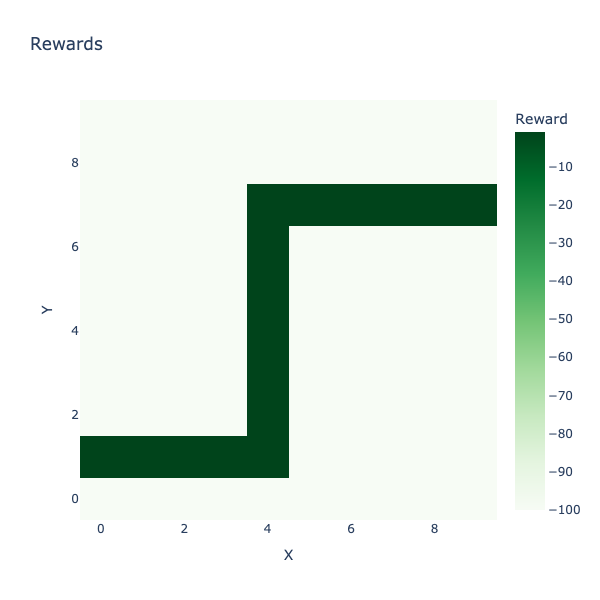

In [86]:
def plot_reward_distribution(env):
    size = env.size
    reward_map = np.full((size, size), -100, dtype=int)
    for x in range(size):
        for y in range(size):
            if ((y == env.start_row - 1 and 0 <= x < env.bend_col) or
                (y == env.end_row - 1 and env.bend_col - 1 <= x < size) or
                (env.start_row - 1 <= y < env.end_row and x == env.bend_col - 1)):
                reward_map[x, y] = -1
    
    fig = go.Figure(data=go.Heatmap(z=reward_map.T, x=np.arange(size), y=np.arange(size), colorscale='Greens', zmin=-100, zmax=-1,
        colorbar=dict(title="Reward"), hovertemplate='x=%{x}<br>y=%{y}<br>reward=%{z}<extra></extra>'))
    fig.update_layout(title='Rewards', xaxis_title='X', yaxis_title='Y', width=600, height=600)
    fig.show()

plot_reward_distribution(env)

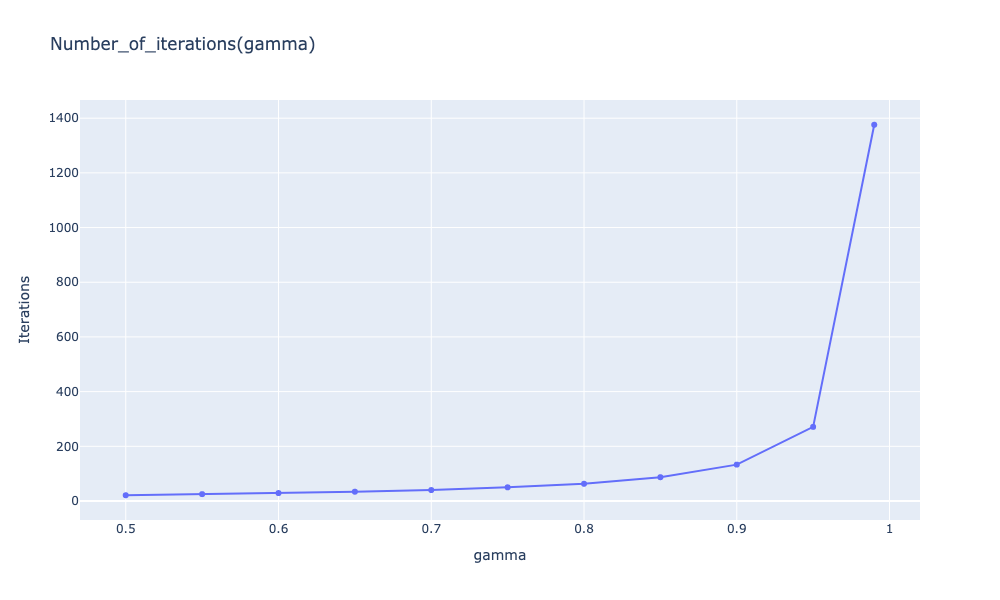

In [89]:
fig_time = go.Figure()
fig_time.add_trace(go.Scatter(x=gamma_range, y=iters_list))
fig_time.update_layout(title='Number_of_iterations(gamma)', xaxis_title='gamma', yaxis_title='Iterations', height=600, width=1000)
fig_time.show()

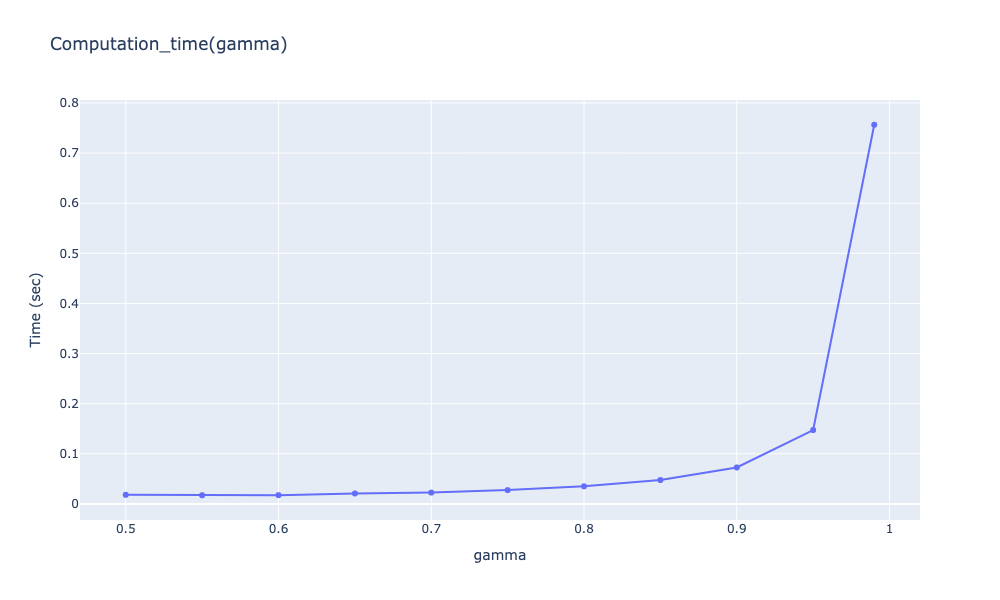

In [92]:
fig_time = go.Figure()
fig_time.add_trace(go.Scatter(x=gamma_range, y=times_list))
fig_time.update_layout(title='Computation_time(gamma)', xaxis_title='gamma', yaxis_title='Time (sec)', height=600, width=1000)
fig_time.show()

**Вывод:** на эксперименте подтвердили, что увеличение коэффициента дисконтирования $\gamma \to 1$ монотонно увеличивает количество итераций Value Iteration, необходимых для достижения заданной точности $\varepsilon$. Это свойство является прямым следствием монотонности погрешности по $\gamma$, которая, в свою очередь, вытекает из неположительности наград и свойств оператора Беллмана.

## Сложный уровень: SARSA vs Q-learning

### SARSA
— предоженный Rummery, Niranjan (1994) TD алгоритм, который обучает политику на основе действий, фактически выбранных агентом, исходя из текущей политики, поэтому такой алгоритм называется on-policy. Обновление происходит по следующему правилу: $Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma Q(s', a') - Q(s, a)]$.

В статье «Convergence Results for Single-Step On-Policy Reinforcement-Learning Algorithms» за авторством Satinder Singh,Tommi Jaakkola,Michael L. Littman, Csaba Szepesvari (2000) доказана сходимость SARSA при выполнении следующих условий:

1. Каждая пара состояние-действие должны посещаться бесконечное число раз

2. Скорость обучения: $\sum_{t=1}^{\infty} \alpha_{t} = \infty, \sum_{t=1}^{\infty} \alpha^2_{t} < \infty$

3. Функция наград ограничена

4. Политика в пределе должна быть жадной

Сложность алгоритма за одну итерацию ${O}(|S| |A|)$ по времени и по памяти.

### Q-learning
— off-policy алгоритм, обучающий оптимальную политику независимо от действий, выбираемых агентом. Обновление функции ценности действий происходит по следующему правилу: $Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'}Q(s', a') - Q(s, a)]$.

Сам алгоритм был изобретён в 1989 Christopher Watkins "Learning from Delayed Rewards". Условия сходимости, выявленные в статье “Q-learning” за авторством Christopher J.C.H. Watkins и Peter Dayan (1992), менее строгие, чем для SARSA:

1. Каждая пара состояние-действие должны посещаться бесконечное число раз

2. Скорость обучения: $\sum_{t=1}^{\infty} a_{t} = \infty, \sum_{t=1}^{\infty} a^2_{t} < \infty$

3. Функция наград ограничена

В этом одно из преимуществ Q-learning  относительно SARSA: он сходится, обучаясь на данных, собранных любой политикой (off-policy). Недостаток его в том, что из-за взятия максимума Q-learning может переоценивать ценность действий и выбирать более рискованные траектории.

Сложность алгоритма за одну итерацию ${O}(|S| |A|)$ по времени и по памяти.

### Сравнение алгоритмов 

**Эксперимент 1:** Динамика суммы наград по эпизодам (усреднение по 100 прогонам). Сравнение SARSA и Q-learning.

Рассмотрим динамику суммы нагад для SARSA и Q-learning по эпизодам для той же среды при старте из состояния $(0,2)$ и окончании в состоянии  $(9,7)$. Используем $\epsilon-$жадную политику, где $\epsilon_0 = 0.1$. Параметр скорости обучения убывает экспоненциально:
$\alpha_0 = 0.5$, $\alpha_t = \frac{1}{(1 + {discount\_rate})^t}$
Для алгоритма SARSA аналогично затухает $\epsilon$ (четвертое условие сходимости). 

Усредним эксперимент по 100 прогонам, критерием останова будет достижение 1000 эпизодов. 


In [104]:
BASE_SEED = 42

class SARSAAgent:
    def __init__(self, env, gamma=0.99, alpha0=0.5, epsilon0=0.5, decay_rate=0.0005, min_epsilon=0.05, seed=None):
        self.env = env
        self.gamma = gamma
        self.alpha0 = alpha0
        self.epsilon0 = epsilon0
        self.decay = decay_rate
        self.min_epsilon = min_epsilon
        self.size = env.size
        self.Q = np.zeros((self.size, self.size, len(env.action_space)))
        self.step_counter = 0
        if seed is not None:
            random.seed(seed)
            np.random.seed(seed)

    def alpha(self):
        return self.alpha0 / (1 + self.decay * self.step_counter)

    def epsilon(self):
        eps = self.epsilon0 * np.exp(-self.decay * self.step_counter)
        return max(self.min_epsilon, eps)

    def choose_action(self, state):
        x,y = int(state[0]), int(state[1])
        if np.random.rand() < self.epsilon():
            return np.random.choice(self.env.action_space)
        else:
            return np.argmax(self.Q[x,y,:])

    def run_episode(self, max_steps=200):
        state = self.env.reset()
        action = self.choose_action(state)
        total_reward = 0
        step = 0
        done = False
        while not done and step < max_steps:
            next_state, reward, done, _ = self.env.step(action)
            if not done:
                next_action = self.choose_action(next_state)
            else:
                next_action = None
            x,y = int(state[0]), int(state[1])
            nx,ny = int(next_state[0]), int(next_state[1])
            td_target = reward + (self.gamma * self.Q[nx,ny,next_action] if not done else 0)
            td_error = td_target - self.Q[x,y,action]
            alpha_t = self.alpha()
            self.Q[x,y,action] += alpha_t * td_error
            state = next_state
            action = next_action if not done else None
            total_reward += reward
            step += 1
            self.step_counter += 1
        return total_reward, step, done


def run_multiple_sarsa(n_runs=100, n_episodes=1000, max_steps=200, verbose=True):
    all_returns = np.zeros((n_runs, n_episodes))
    all_lengths = np.zeros((n_runs, n_episodes))
    all_success = np.zeros((n_runs, n_episodes))
    
    for run in range(n_runs):
        seed = BASE_SEED + run
        env = zigzag_mdp()
        agent = SARSAAgent(env, gamma=0.99, alpha0=0.5, epsilon0=0.5,
                           decay_rate=0.0005, min_epsilon=0.05, seed=seed)
        for ep in range(n_episodes):
            ret, steps, done = agent.run_episode(max_steps=max_steps)
            all_returns[run, ep] = ret
            all_lengths[run, ep] = steps
            all_success[run, ep] = 1 if done else 0
        if verbose and (run+1) % 10 == 0:
            print(f"Completed {run+1}/{n_runs} runs")
    
    mean_returns = np.mean(all_returns, axis=0)
    std_returns = np.std(all_returns, axis=0)
    mean_lengths = np.mean(all_lengths, axis=0)
    std_lengths = np.std(all_lengths, axis=0)
    mean_success = np.mean(all_success, axis=0)
    std_success = np.std(all_success, axis=0)
    
    return (mean_returns, std_returns), (mean_lengths, std_lengths), (mean_success, std_success)

print("Запуск 100 прогонов SARSA по 1000 эпизодов...")
(mean_ret_sarsa, std_ret_sarsa), (mean_len_sarsa, std_len_sarsa), (mean_succ_sarsa, std_succ_sarsa) = run_multiple_sarsa(
    n_runs=100, n_episodes=1000, max_steps=200, verbose=True
)


Запуск 100 прогонов SARSA по 1000 эпизодов...
Completed 10/100 runs
Completed 20/100 runs
Completed 30/100 runs
Completed 40/100 runs
Completed 50/100 runs
Completed 60/100 runs
Completed 70/100 runs
Completed 80/100 runs
Completed 90/100 runs
Completed 100/100 runs


In [106]:
class QLearningAgent:
    def __init__(self, env, gamma=0.99, alpha0=0.5, epsilon0=0.5, decay_rate=0.0005, min_epsilon=0.05):
        self.env = env
        self.gamma = gamma
        self.alpha0 = alpha0
        self.epsilon0 = epsilon0
        self.decay = decay_rate
        self.min_epsilon = min_epsilon
        self.size = env.size
        self.Q = np.zeros((self.size, self.size, len(env.action_space)))
        self.step_counter = 0

    def alpha(self):
        return self.alpha0 / (1 + self.decay * self.step_counter)

    def epsilon(self):
        eps = self.epsilon0 * np.exp(-self.decay * self.step_counter)
        return max(self.min_epsilon, eps)

    def choose_action(self, state):
        x,y = int(state[0]), int(state[1])
        if np.random.rand() < self.epsilon():
            return np.random.choice(self.env.action_space)
        else:
            return np.argmax(self.Q[x,y,:])

    def run_episode(self, max_steps=200):
        state = self.env.reset()
        total_reward = 0
        step = 0
        done = False
        while not done and step < max_steps:
            action = self.choose_action(state)
            next_state, reward, done, _ = self.env.step(action)
            x,y = int(state[0]), int(state[1])
            nx,ny = int(next_state[0]), int(next_state[1])
            # Q-learning update
            best_next = np.max(self.Q[nx,ny,:]) if not done else 0
            td_target = reward + self.gamma * best_next
            td_error = td_target - self.Q[x,y,action]
            alpha_t = self.alpha()
            self.Q[x,y,action] += alpha_t * td_error

            state = next_state
            total_reward += reward
            step += 1
            self.step_counter += 1
        return total_reward, step, done

def run_multiple_qlearning(n_runs=100, n_episodes=1000, max_steps=200, 
                           gamma=0.99, alpha0=0.5, epsilon0=0.5, decay_rate=0.0005, min_epsilon=0.05, verbose=True):
    all_returns = np.zeros((n_runs, n_episodes))
    all_lengths = np.zeros((n_runs, n_episodes))
    all_success = np.zeros((n_runs, n_episodes))
    
    for run in range(n_runs):
        env = zigzag_mdp()
        agent = QLearningAgent(env, gamma=gamma, alpha0=alpha0, epsilon0=epsilon0,
                               decay_rate=decay_rate, min_epsilon=min_epsilon)
        for ep in range(n_episodes):
            ret, steps, done = agent.run_episode(max_steps=max_steps)
            all_returns[run, ep] = ret
            all_lengths[run, ep] = steps
            all_success[run, ep] = 1 if done else 0
        if verbose and (run+1) % 10 == 0:
            print(f"Completed {run+1}/{n_runs} runs")
    
    mean_returns = np.mean(all_returns, axis=0)
    std_returns = np.std(all_returns, axis=0)
    mean_lengths = np.mean(all_lengths, axis=0)
    std_lengths = np.std(all_lengths, axis=0)
    mean_success = np.mean(all_success, axis=0)
    std_success = np.std(all_success, axis=0)
    
    return (mean_returns, std_returns, mean_lengths, std_lengths, mean_success, std_success)

In [108]:
(mean_ret, std_ret, mean_len, std_len, mean_suc, std_suc) = run_multiple_qlearning(n_runs=100, n_episodes=1000, max_steps=200, 
                           gamma=0.5, alpha0=0.5, epsilon0=0.5, decay_rate=0.0005, min_epsilon=0.05)
    
episodes = np.arange(1, 1001)


Completed 10/100 runs
Completed 20/100 runs
Completed 30/100 runs
Completed 40/100 runs
Completed 50/100 runs
Completed 60/100 runs
Completed 70/100 runs
Completed 80/100 runs
Completed 90/100 runs
Completed 100/100 runs


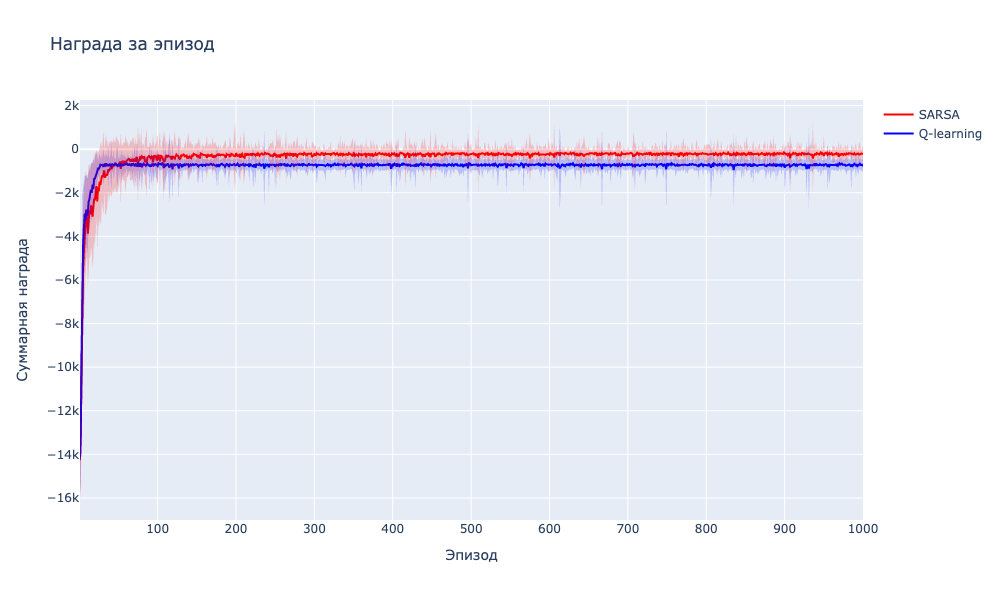

In [112]:
fig_rew = go.Figure()
fig_rew.add_trace(go.Scatter(x=episodes, y=mean_ret_sarsa, name='SARSA', line=dict(color='red', width=2)))
fig_rew.add_trace(go.Scatter(x=episodes, y=mean_ret, name='Q-learning', line=dict(color='blue', width=2)))

fig_rew.add_trace(go.Scatter(
    x=np.concatenate([episodes, episodes[::-1]]),
    y=np.concatenate([mean_ret - std_ret, (mean_ret + std_ret)[::-1]]),
    fill='toself',
    fillcolor='rgba(0, 0, 255, 0.2)',
    line=dict(color='rgba(0,0,0,0)'),
    showlegend=False,
    name='Q-learning CI'
))

fig_rew.add_trace(go.Scatter(
    x=np.concatenate([episodes, episodes[::-1]]),
    y=np.concatenate([mean_ret_sarsa - std_ret_sarsa, (mean_ret_sarsa + std_ret_sarsa)[::-1]]),
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.2)',
    line=dict(color='rgba(0,0,0,0)'),
    showlegend=False,
    name='SARSA CI'
))

fig_rew.update_layout(title='Награда за эпизод',
                      height=600,
                      width=1000,
                       xaxis_title='Эпизод',
                       yaxis_title='Суммарная награда',
                       hovermode='x unified'
                     )
fig_rew.show()

На графике мы увидим, что спустя первые 100 итераций SARSA показывает стабильно лучший результат. Это объясняется переоценкой ценности в алгоритме Q-learning. Результаты алгоритмов отличаются из-за отсутствия условия сходимости о посещении всех пар состояние-действие бесконечное число раз: агент быстро находит оптимальную траекторию и перестаёт исследовать, но при случайных действиях он может уйти в неизвестные области и получить доход ниже ожидаемого.

**Эксперимент 2:** Сравнение поэпизодного расстояния между текущей V-функцией и оптимальной V* (полученной Value Iteration) при старте из случайного состояния.

Для обеспечения сходимости к оптимальной функции ценности добавим условие старта из случайного состояния среды. Сравним поэпизодно расстояние между $\hat V^*$, полученной с помощью Value Iteration, и текущей  $V-$функции для алгоритмов SARSA, Q-learning. 

In [116]:
def compute_optimal_V(env, gamma=0.99, epsilon=1e-6):
    agent = ValueIterationAgent(env, gamma=gamma, epsilon=epsilon)
    agent.value_iteration()
    return agent.values


def train_random_start(env, agent_class, agent_params, n_episodes=1000, max_steps=200):
    agent = agent_class(env, **agent_params)
    V_star = compute_optimal_V(env, gamma=agent.gamma, epsilon=1e-6)
    distances = np.zeros(n_episodes)

    for ep in range(n_episodes):
        while True:
            x = np.random.randint(0, env.size)
            y = np.random.randint(0, env.size)
            if not (x == env.size-1 and y == env.end_row):
                break
        state = np.array([x, y])
        env.state = state.copy()

        done = False
        step = 0
        total_reward = 0

        if agent_class.__name__ == 'SARSAAgent':
            action = agent.choose_action(state)
            while not done and step < max_steps:
                next_state, reward, done, _ = env.step(action)
                if not done:
                    next_action = agent.choose_action(next_state)
                else:
                    next_action = None

                x_, y_ = int(state[0]), int(state[1])
                nx, ny = int(next_state[0]), int(next_state[1])
                td_target = reward + (agent.gamma * agent.Q[nx, ny, next_action] if not done else 0)
                td_error = td_target - agent.Q[x_, y_, action]
                alpha_t = agent.alpha()
                agent.Q[x_, y_, action] += alpha_t * td_error

                state = next_state
                action = next_action if not done else None
                total_reward += reward
                step += 1
                agent.step_counter += 1
        else:
            while not done and step < max_steps:
                action = agent.choose_action(state)
                next_state, reward, done, _ = env.step(action)

                x_, y_ = int(state[0]), int(state[1])
                nx, ny = int(next_state[0]), int(next_state[1])
                best_next = np.max(agent.Q[nx, ny, :]) if not done else 0
                td_target = reward + agent.gamma * best_next
                td_error = td_target - agent.Q[x_, y_, action]
                alpha_t = agent.alpha()
                agent.Q[x_, y_, action] += alpha_t * td_error

                state = next_state
                total_reward += reward
                step += 1
                agent.step_counter += 1

        current_V = np.max(agent.Q, axis=2)
        dist = np.max(np.abs(current_V - V_star))
        distances[ep] = dist

    return distances

def run_multiple_random_start(env, agent_class, agent_params, n_runs=100, n_episodes=1000, max_steps=200):
    all_distances = np.zeros((n_runs, n_episodes))
    for run in tqdm(range(n_runs), desc=f"{agent_class.__name__}"):
        dist = train_random_start(env, agent_class, agent_params, n_episodes, max_steps)
        all_distances[run] = dist
    mean_dist = np.mean(all_distances, axis=0)
    std_dist = np.std(all_distances, axis=0)
    return mean_dist, std_dist

In [118]:
env = zigzag_mdp(size=10, start_row=2, end_row=8, bend_col=5)

common_params = {
    'gamma': 0.8,
    'alpha0': 0.5,
    'epsilon0': 0.5,
    'decay_rate': 0.0005,
    'min_epsilon': 0.05
}

n_runs = 100
n_episodes = 1000
max_steps = 1000

sarsa_mean, sarsa_std = run_multiple_random_start(env, SARSAAgent, common_params, n_runs, n_episodes, max_steps)

ql_mean, ql_std = run_multiple_random_start(env, QLearningAgent, common_params, n_runs, n_episodes, max_steps)

QLearningAgent: 100%|█████████████████████████| 100/100 [27:30<00:00, 16.51s/it]


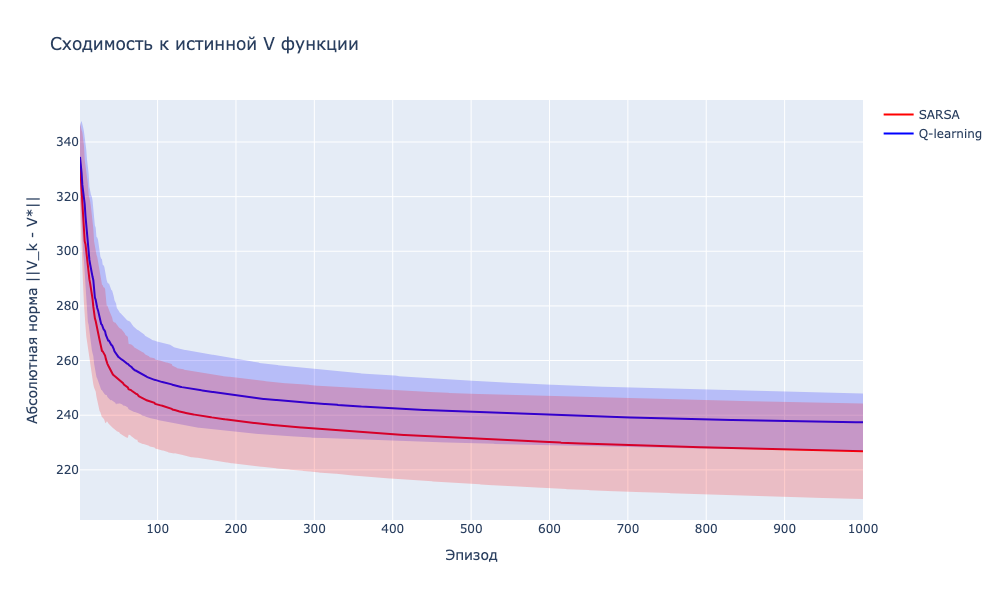

In [120]:
fig_2 = go.Figure()
fig_2.add_trace(go.Scatter(x=episodes, y=sarsa_mean, name='SARSA', line=dict(color='red', width=2)))
fig_2.add_trace(go.Scatter(x=episodes, y=ql_mean, name='Q-learning', line=dict(color='blue', width=2)))

fig_2.add_trace(go.Scatter(
    x=np.concatenate([episodes, episodes[::-1]]),
    y=np.concatenate([ql_mean - ql_std, (ql_mean + ql_std)[::-1]]),
    fill='toself',ghbn 
    fillcolor='rgba(0, 0, 255, 0.2)',
    line=dict(color='rgba(0,0,0,0)'),
    showlegend=False,
    name='Q-learning CI'
))

fig_2.add_trace(go.Scatter(
    x=np.concatenate([episodes, episodes[::-1]]),
    y=np.concatenate([sarsa_mean - sarsa_std, (sarsa_mean + sarsa_std)[::-1]]),
    fill='toself',
    fillcolor='rgba(255, 0, 0, 0.2)',
    line=dict(color='rgba(0,0,0,0)'),
    showlegend=False,
    name='SARSA CI'
))

fig_2.update_layout(title='Сходимость к истинной V функции',
                      height=600,
                      width=1000,
                       xaxis_title='Эпизод',
                       yaxis_title='Абсолютная норма ||V_k - V*||',
                       hovermode='x unified'
                     )
fig_2.show()

Из графика убывания нормы разности оценки $V-$функции, можно заключить, что алгоритмы сходятся к оптимальной $V^*$.


#### Выводы:
1. В среде с отрицательными наградами и штрафом за сход с траектории SARSA демонстрирует более стабильное и высокое качество обучения, чем Q-learning, при одинаковых гиперпараметрах. Q-learning страдает от переоценки ценности, что проявляется в периодических провалах суммарной награды.

Q-learning использует максимум по следующему действию при обновлении, что приводит к переоценке ценности. Это заставляет агента выбирать рискованные действия, которые в редких случаях дают высокую награду, но чаще – приводят к сходу с траектории и большому штрафу.
SARSA, напротив, обновляет Q-значение на основе фактически выбранного следующего действия (ε-жадного). Это делает алгоритм более консервативным и устойчивым к переоценке.
Поскольку ε и α экспоненциально затухают, после ~100 эпизодов исследование почти прекращается. Однако если агент всё же совершает случайное действие (из-за остаточного ε), Q-learning может попасть в область с низкой наградой, а SARSA – быстрее вернуться на траекторию.


2. Оба алгоритма сходятся к истонной функции ценности при выполнении условий сходимости

## Литература:

- Richard S. Sutton, Andrew G. Barto: Reinforcement Learning: An Introduction (2nd edition). Massachusetts: The MIT Press Cambridge, 2014 – 2015

- Satinder Singh, Tommi Jaakkola, Michael L. Littman, Csaba Szepesvari: Convergence Results for Single-Step On-Policy Reinforcement-Learning Algorithms. Kluwer Academic Publishers, 2000

- Christopher J.C.H. Watkins: Learning From Delayed Rewards. PhD Thesis, University of Cambridge, England, 1989

- Christopher J.C.H. Watkins, Peter Dayan: Q-learning. Boston: Kluwer Academic Publishers, 1992
